(ch:data-visualization)=
# 데이터 시각화

펭귄 데이터셋을 활용하여 기술통계와 선형 상관관계 장에서 사용된 시각화 도구를 종합적으로 소개한다.

**기본 설정**

탐색적 데이터 분석(EDA)에 필요한 핵심 라이브러리를 불러온다.

- `numpy`: 수치 연산
- `pandas`: 데이터프레임 기반 데이터 처리
- `matplotlib.pyplot`: 기본 시각화
- `seaborn`: 통계 시각화 및 펭귄 데이터셋 제공

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.precision', 6)

## 펭귄 데이터셋

펭귄 데이터셋은 남극 파머 군도<font size='2'>Palmer Archipelago</font>의 세 섬에서 관찰된 세 종(species)의 펭귄 344마리에 대한 측정값을 담고 있으며, `seaborn` 라이브러리에서 기본 제공한다.

| 특성 | 의미 |
| :--- | :--- |
| `species` | 펭귄 종 (Adelie, Chinstrap, Gentoo) |
| `island` | 관찰된 섬 (Torgersen, Biscoe, Dream) |
| `bill_length_mm` | 부리 길이 (mm) |
| `bill_depth_mm` | 부리 두께 (mm) |
| `flipper_length_mm` | 날개 길이 (mm) |
| `body_mass_g` | 몸무게 (g) |
| `sex` | 성별 (Male, Female) |

In [3]:
penguins = sns.load_dataset('penguins')
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


데이터프레임의 기본 정보를 확인한다.
수치형 특성 4개와 범주형 특성 3개로 구성되어 있으며, 일부 특성에 결측치가 존재한다.

In [4]:
penguins.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 24.9 KB


부리와 날개 특성에 2개, 성별 특성에 11개의 결측치가 포함되어 있다.
결측치를 포함한 모든 데이터 샘플(행)을 제거하고
총 333개의 데이터 샘플만 남긴다.

In [5]:
penguins = penguins.dropna()
penguins.info()

<class 'pandas.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    str    
 1   island             333 non-null    str    
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 26.7 KB


## 그래프 스타일 지정

`plt.rc()` 함수는 앞으로 그려지는 모든 그래프의 스타일을 설정한다.

```python
plt.rc(그룹, 키워드=값, ...)
```

자주 사용하는 그룹과 설정값은 다음과 같다.

| 그룹 | 키워드 | 의미 |
| :--- | :--- | :--- |
| `figure` | `figsize` | 그래프 가로, 세로 크기 (inch) |
| `font` | `size` | 기본 글자 크기 |
| `axes` | `labelsize` | 축 이름 크기 |
| `axes` | `titlesize` | 그래프 제목 크기 |
| `legend` | `fontsize` | 범례 글자 크기 |
| `xtick` | `labelsize` | x축 눈금 레이블 크기 |
| `ytick` | `labelsize` | y축 눈금 레이블 크기 |

아래 코드는 그래프 기본 설정을 명시해서 보여준다.

In [6]:
plt.rc('figure', figsize=(6.4, 4.8))
plt.rc('font',   size=10)
plt.rc('axes',   labelsize=10, titlesize=12)
plt.rc('legend', fontsize=10)
plt.rc('xtick',  labelsize=10)
plt.rc('ytick',  labelsize=10)

## 그래프 그리기 세 가지 방식

파이썬으로 그래프를 그리는 방식은 크게 세 가지로 나뉜다.
일반적으로 세 방식 모두 사용되므로, 코드를 읽을 때 어떤 방식이 사용되었는지 구분할 수 있어야 한다.

**방식 1: `matplotlib` 직접 사용**

`matplotlib`은 두 가지 인터페이스를 제공한다. 데이터는 어레이나 시리즈 형태로 전달한다.

- **pyplot 함수형**: `matplotlib.pyplot`(보통 `plt`) 모듈의 함수를 직접 호출한다. 암묵적으로 현재 활성화된 axes에 그래프를 그린다.
  - 히스토그램: `plt.hist(데이터, ...)`
  - 산점도: `plt.scatter(x, y, ...)`
- **객체 지향(OO)**: `Axes` 객체(`ax`)를 명시적으로 지정하여 메서드를 호출한다. 서브플롯을 여러 개 다룰 때 주로 사용한다.
  - 히스토그램: `ax.hist(데이터, ...)`
  - 산점도: `ax.scatter(x, y, ...)`

**방식 2: 판다스 데이터프레임/시리즈 메서드**

판다스가 내부적으로 `matplotlib`을 호출하여 그래프를 그려 주는 메서드를 사용한다.
데이터프레임이나 시리즈에서 직접 메서드를 호출하면 되므로 코드가 짧고 직관적이다.

- 히스토그램: `시리즈.hist(...)` 또는 `데이터프레임.hist(...)`
- 상자 그림: `데이터프레임.boxplot(...)`
- 산점도: `데이터프레임.plot.scatter(x=..., y=...)`

**방식 3: `seaborn` 라이브러리 활용**

통계 시각화에 특화된 `seaborn` 라이브러리(보통 `sns`로 불러옴)는 내부적으로 `matplotlib`을 사용하지만,
더 정돈된 모양과 통계적 기능(회귀선, 분포 추정 등)을 기본으로 제공한다.
데이터프레임을 통째로 받아 `x`, `y`, `hue` 등의 인자로 그래프를 지정한다.

- 히스토그램: `sns.histplot(data=..., x=..., hue=...)`
- 산점도: `sns.scatterplot(data=..., x=..., y=..., hue=...)`
- 산점도 + 회귀선: `sns.regplot(...)`, `sns.lmplot(...)`
- 히트맵: `sns.heatmap(...)`

세 방식 모두 결국 `matplotlib`을 거쳐 그래프가 그려지므로, `plt.xlabel()`, `plt.title()`, `plt.show()`와 같은
꾸미기 함수는 어느 방식과도 함께 사용할 수 있다.

## 1차원 데이터 시각화

하나의 특성의 분포를 살펴보는 그래프로 **히스토그램**과 **상자 그림**을 사용한다.

### 히스토그램

**히스토그램**<font size='2'>histogram</font>은 데이터를 일정한 구간(bin)으로 나누어 각 구간에 속하는 값의 빈도(개수)를 막대로 표현하며,
데이터의 전체적인 분포를 한눈에 파악할 수 있게 도와준다.
아래 코드는 펭귄의 부리 길이 분포를 히스토그램으로 그린다.

**방식 1: `plt.hist()` 함수 직접 호출**

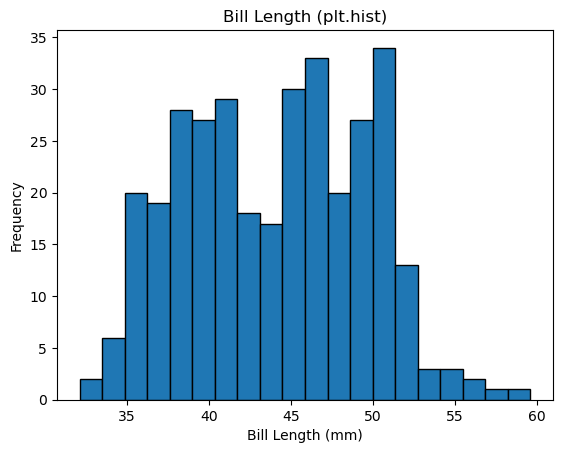

In [7]:
plt.hist(penguins['bill_length_mm'], bins=20, edgecolor='black')

plt.xlabel('Bill Length (mm)')
plt.ylabel('Frequency')
plt.title('Bill Length (plt.hist)')
plt.show()

위 코드는 구간 개수(`bins`)를 20개로 지정하였기에 전체 데이터 범위를 20등분하였다.
하지만 데이터 범위와 구간을 직접 설정할 수 있다.
예를 들어 아래 코드는 전체 데이터 범위보다 좀 더 넓은 영역에 대해
하나의 구간의 크기를 3mm로 지정한다.
범위가 대략 32mm에서 60mm사이이기에 10개의 구간으로 나뉘어진다.

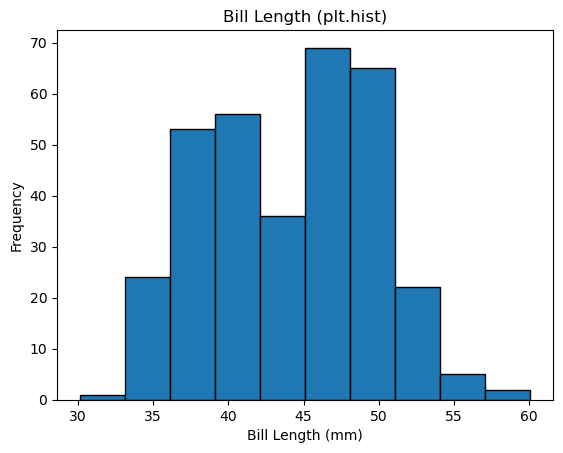

In [8]:
bl_min = penguins['bill_length_mm'].min()
bl_max = penguins['bill_length_mm'].max()
bins = np.arange(bl_min-2, bl_max + 2, 3) # 구간 크기: 3mm

plt.hist(penguins['bill_length_mm'], bins=bins, edgecolor='black')

plt.xlabel('Bill Length (mm)')
plt.ylabel('Frequency')
plt.title('Bill Length (plt.hist)')
plt.show()

**방식 2: 시리즈의 `hist()` 메서드**

데이터프레임에서 하나의 특성만 지정하여 생성된 시리즈 객체의 `hist()` 메서드를
호출하면 내부적으로 `plt.hist()` 함수가 호출되어 시리즈에 포함된
값들의 히스토그램을 그린다.

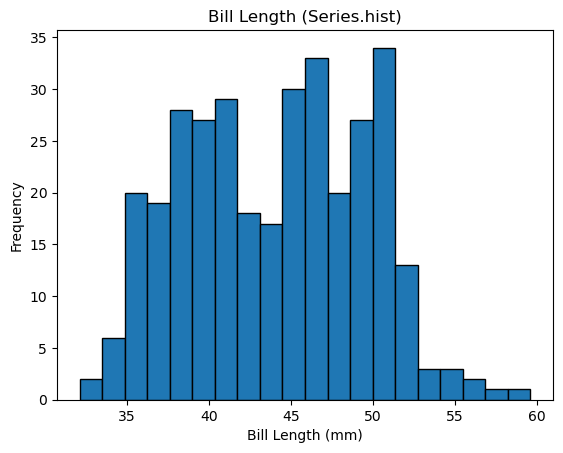

In [9]:
penguins['bill_length_mm'].hist(bins=20, edgecolor='black', grid=False)

plt.xlabel('Bill Length (mm)')
plt.ylabel('Frequency')
plt.title('Bill Length (Series.hist)')
plt.show()

방식 2에서도 `plt.xlabel()`, `plt.title()`, `plt.show()`와 같은 `pyplot` 함수를 함께 사용해
축 이름과 제목 등을 지정한다.
즉, 그래프를 어떻게 그릴지 결정하는 부분(데이터프레임 메서드 vs `pyplot` 함수)만 다를 뿐,
그래프 꾸미기 부분은 두 방식 모두 `matplotlib.pyplot`을 사용한다.

**방식 3: `seaborn`의 `histplot()` 함수**

`seaborn` 라이브러리의 `histplot()` 함수는 보다 정돈된 형태의 히스토그램을 그린다.
`data` 키워드 인자로 데이터프레임을 통째로 전달하고 축에 사용될 두 개의 특성만 지정하면 되므로 코드가 매우 짧다.
또한 막대의 색, 투명도 등 시각적 표현이 기본적으로 정돈되어 있어, 보고서나 발표용 그래프에 적합하다.

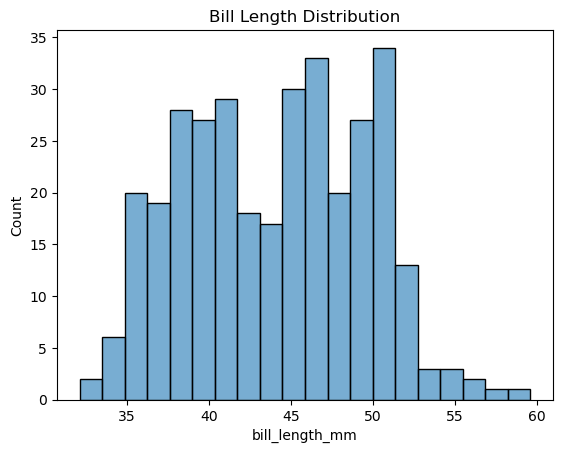

In [10]:
sns.histplot(data=penguins, x='bill_length_mm', bins=20, alpha=0.6)

plt.title('Bill Length Distribution')
plt.show()

`sns.histplot()` 함수는 데이터프레임에 포함된 특성 이름을 축 이름으로 사용한다.
반면에 `plt.title()`, `plt.show()` 등은 `matplotlib.pyplot`을 활용한다.

**종별 히스토그램**

`sns.histplot()` 함수의 `hue` 키워드 인자를 사용하면 예를 들어 종(species)별로 색을 달리하여 동일한 그래프 위에 겹쳐 그릴 수 있다.
이렇게 하면 종에 따라 부리 길이의 분포가 어떻게 다른지 한눈에 비교할 수 있다.
아래 코드에서 `alpha` 키워드 인자는 0부터 1 사이의 값을 받아 색깔의 농도를 결정한다.

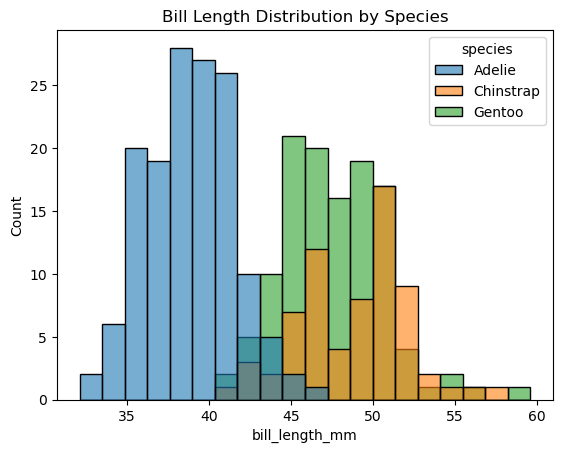

In [11]:
sns.histplot(data=penguins, x='bill_length_mm', hue='species', bins=20, alpha=0.6)

plt.title('Bill Length Distribution by Species')
plt.show()

### 상자 그림

**상자 그림**<font size='2'>box plot</font>은 사분위수, 중앙값, 이상치를 시각적으로 표현하여 데이터의 퍼짐 정도와 이상치를 한눈에 파악할 수 있게 해준다.
아래 코드는 펭귄의 몸무게(`body_mass_g`)에 대한 상자 그림을 그린다.

상자 그림은 주로 데이터프레임의 `boxplot()` 메서드(방식 2)를 사용한다.
여러 특성을 한 번에 그리거나 그룹별로 나누어 그릴 때 편리하다.

`boxplot()` 함수의 인자로 사용된 값들은 다음과 같다.
`flierprops` 키워드 인자는 IQR 기준 이상치를 표시하는 점의 스타일을
지정하는데 `body_mass_g` 전체 데이터 상으로는 해당 샘플이 없다.

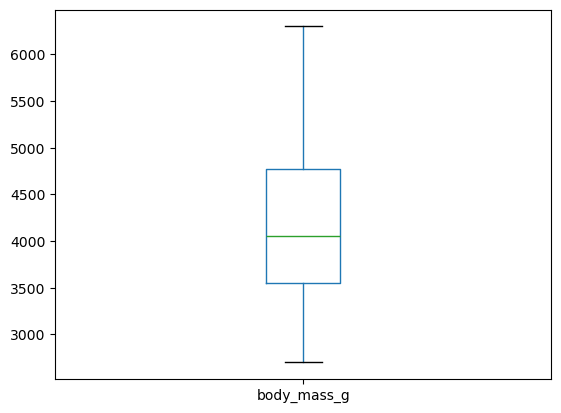

In [12]:
penguins.boxplot(
    column=['body_mass_g'],
    grid=False,
    flierprops=dict(marker='o', markerfacecolor='red', markersize=5)
)
plt.show()

**종별 상자 그림**

`bosplot()` 메서드는 여러 특성의 상자 그림을 다양한 방식으로 동시에 그릴 수 있다.
아래 코드에 사용된 키워드 인자 옵션은 다음과 같다.

- `by='species'`: 종별 그룹으로 나눠 여러 특성의 상자 그림을 그린다.
- `layout=(2, 2)`: 4개의 특성 각각에 대한 상자 그림을 2x2 격자 모양으로 배치한다.
- `sharey=False`: y-축 눈금을 공유하지 않도록 한다.
    반면에 x-축 눈굼은 공유되도록 기본 설정 `sharex=True`을 그대로 유지한다.

:::{tip}

그래프를 그리는 함수의 `figsize` 키워드 인자는 그려지는 그래프의 크기를 전역 설정 대신 지역적으로 지정한다.
:::

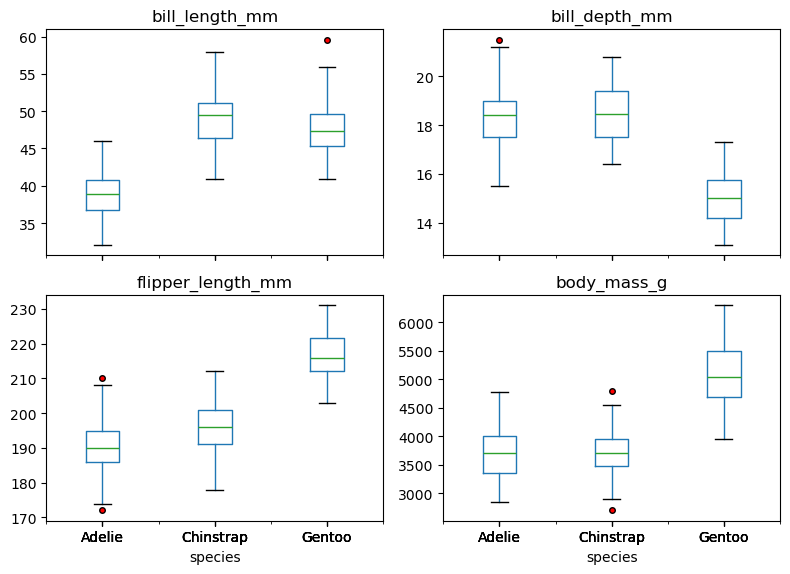

In [13]:
penguins.boxplot(
    column=['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'],
    by='species',
    layout=(2, 2),
    figsize=(8, 6),
    grid=False,
    sharey=False,
    flierprops=dict(marker='o', markerfacecolor='red', markersize=4)
)

plt.suptitle('')   # 전체 제목 제거
plt.tight_layout() # 레이아웃 조정
plt.show()

펭귄의 몸무게 전체를 대상으로 했을 때는 보이지 않았던 IQR 기준의 이상치가 종별로 확인하니 일부 종에서 이상치가 확인되며, 다른 특성에서도 유사한 결과가 나왔다.

## 2차원 데이터 시각화

두 특성 사이의 관계를 살펴보는 데에는 **산점도**가 가장 기본이며,
여기에 **회귀선**, **산점도 행렬**, **상관관계 히트맵**을 더해 다각도로 분석할 수 있다.

### 산점도

**방식 1: `plt.scatter()` 함수 직접 호출**

아래 그래프는 부리 길이(`bill_length_mm`)와 부리 두께(`bill_depth_mm`)의 관계는 `plt.scatter()`로 그려 본다.
전체적으로 약한 음의 상관관계처럼 보이는데, 이 관계가 정말 음의 상관관계인지는 뒤에서 종별로 나눠 살펴본다.

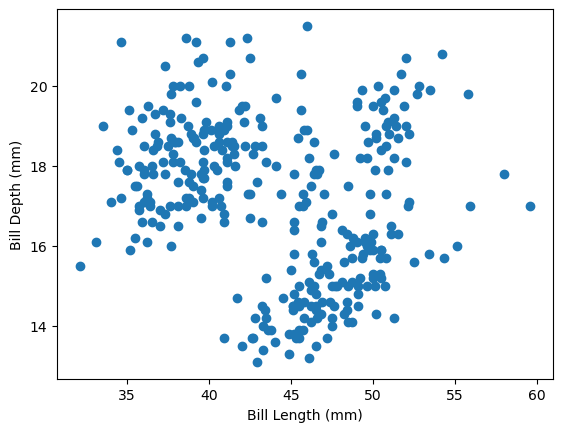

In [14]:
plt.scatter(penguins['bill_length_mm'], penguins['bill_depth_mm'])

plt.xlabel('Bill Length (mm)')
plt.ylabel('Bill Depth (mm)')
plt.show()

**방식 2: 데이터프레임의 `plot.scatter()` 메서드**

아래 그래프는 날개 길이(`flipper_length_mm`)와 몸무게(`body_mass_g`)의 관계를
데이터프레임의 `plot.scatter()` 메서드를 이용하여 산점도로 그린다.
두 특성 사이에 양의 선형 상관관계가 뚜렷하게 나타난다.

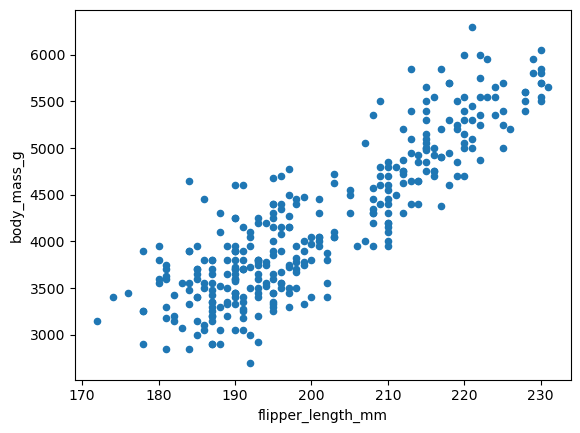

In [15]:
penguins.plot.scatter(x='flipper_length_mm', y='body_mass_g')

plt.show()

**방식 3: `sns.scatterplot()` 함수**

`sns.scatterplot()` 함수가 산점도를 그린다.

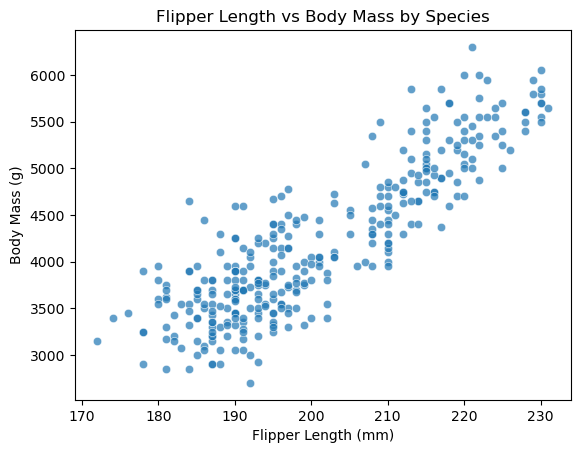

In [16]:
sns.scatterplot(data=penguins, x='flipper_length_mm', y='body_mass_g', alpha=0.7)

plt.title('Flipper Length vs Body Mass by Species')
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')
plt.show()

'hue' 키워드 인자로 종을 지정하면 종별 색상 구분이 자동으로 이뤄진다.

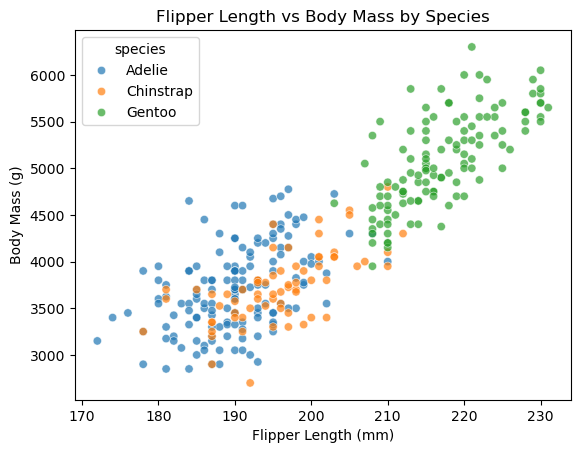

In [17]:
sns.scatterplot(data=penguins, x='flipper_length_mm', y='body_mass_g',
                hue='species', alpha=0.7)

plt.title('Flipper Length vs Body Mass by Species')
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')
plt.show()

### 산점도와 회귀선

`seaborn`의 `regplot()` 함수는 산점도와 함께 선형 회귀선을 그려 준다.
선형 회귀선은 두 특성 사이의 상관관계를 보다 직접적으로 보여준다.

- `scatter_kws` 키워드 인자는 점의 색깔, 크기 등의 특성을 사전 자료형으로 지정한다.

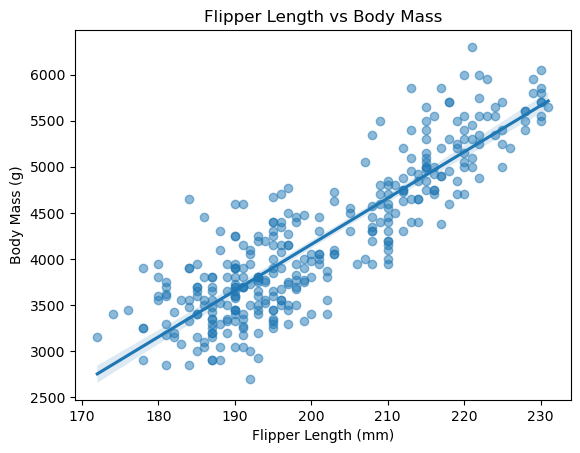

In [18]:
sns.regplot(data=penguins,
            x='flipper_length_mm',
            y='body_mass_g',
            scatter_kws={'alpha': 0.5})

plt.title('Flipper Length vs Body Mass')
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')
plt.show()

회귀선 주위의 음영은 95% 신뢰구간<font size='2'>confidence interval</font>을 나타낸다.
데이터 수가 적거나 데이터가 회귀선 주위에 넓게 퍼져 있을수록 음영 폭이 넓어진다.
`ci=None`을 지정하면 신뢰구간 음영을 없앨 수 있다.

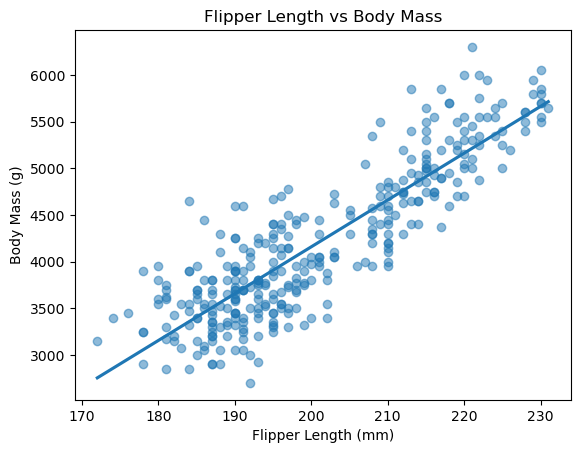

In [19]:
sns.regplot(data=penguins,
            x='flipper_length_mm',
            y='body_mass_g',
            scatter_kws={'alpha': 0.5},
            ci=None)  # 신뢰 구간 제거

plt.title('Flipper Length vs Body Mass')
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')
plt.show()

**종별 회귀선**

`lmplot()` 함수는 `hue` 인자를 통해 종별로 색상을 달리하여 산점도와 회귀선을 그릴 수 있다.
앞서 부리 길이와 부리 두께의 산점도는 음의 상관관계처럼 보였지만, 종별로 나눠 보면 각 종 안에서는 
오히려 양의 상관관계가 나타난다.
이는 이전 장에서 설명한 대로 심슨의 역설<font size='2'>Simpson's paradox</font>의 한 예이다.

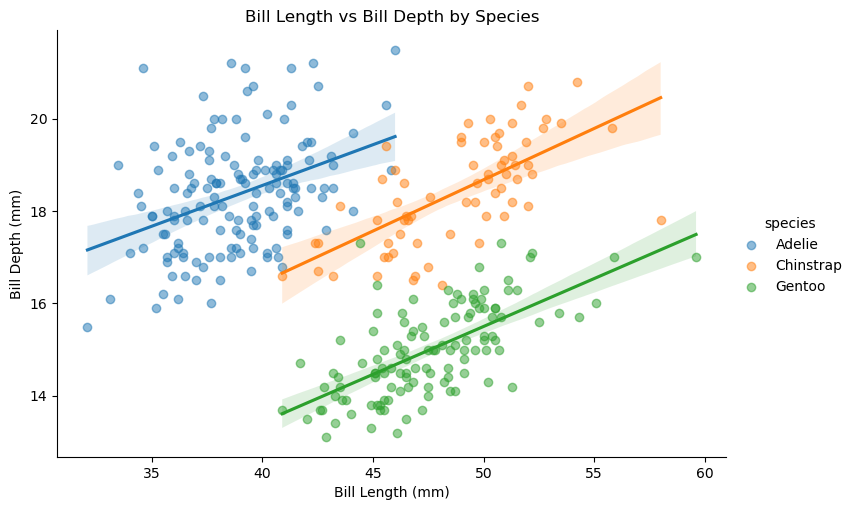

In [20]:
sns.lmplot(data=penguins,
           x='bill_length_mm',
           y='bill_depth_mm',
           hue='species',
           height=5,
           aspect=1.5,
           scatter_kws={'alpha': 0.5})

plt.title('Bill Length vs Bill Depth by Species')
plt.xlabel('Bill Length (mm)')
plt.ylabel('Bill Depth (mm)')
plt.show()

### 산점도 행렬

데이터프레임에 포함된 모든 수치형 특성 사이의 관계를 한 번에 보고 싶다면 
산점도 행렬<font size='2'>scatter matrix</font>을 사용한다.
대각선에는 각 특성의 히스토그램이, 그 외 영역에는 두 특성의 산점도가 표시된다.

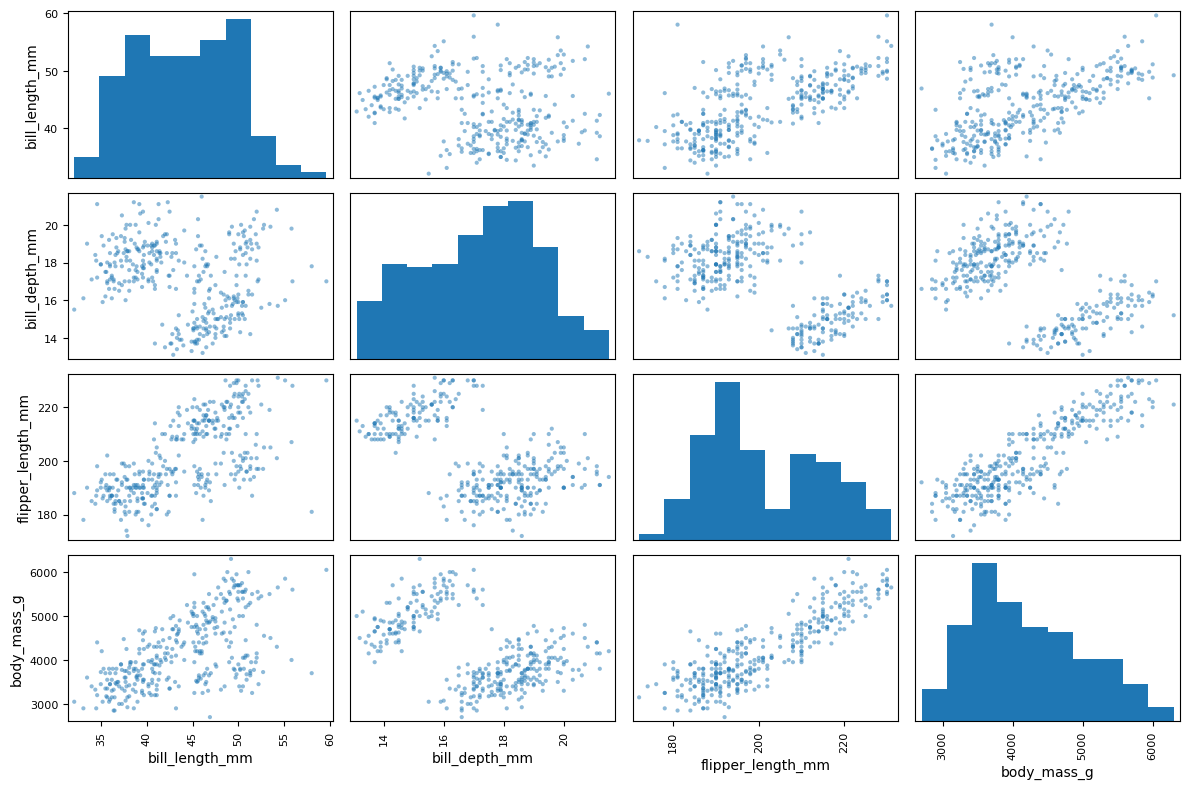

In [21]:
from pandas.plotting import scatter_matrix
scatter_matrix(penguins, figsize=(12, 8))

plt.tight_layout()
plt.show()

### 상관관계 히트맵

**히트맵**<font size='2'>heatmap</font>은 행렬 형태의 값을 색상의 농도로 표현하는 그래프이다.
상관계수 행렬을 히트맵으로 그리면 어떤 특성 쌍이 강한 양 또는 음의 상관관계를 갖는지 한눈에 파악할 수 있다.

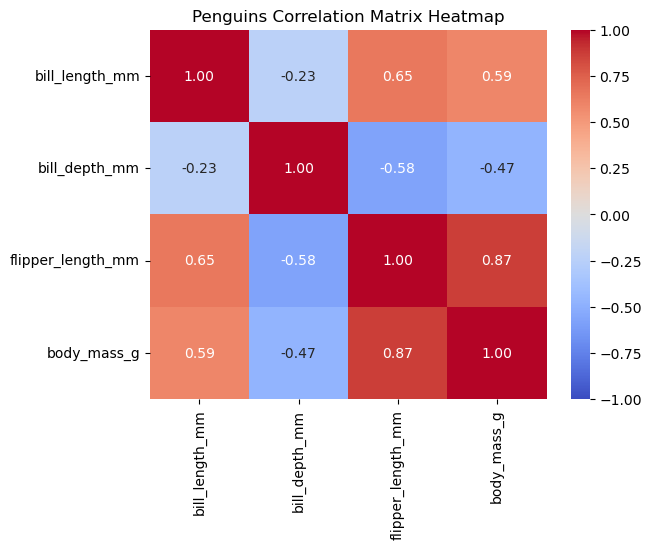

In [22]:
corr_matrix = penguins.corr(numeric_only=True)

sns.heatmap(corr_matrix,
            annot=True,        # 각 셀에 상관계수 값 표시
            cmap='coolwarm',   # 색상 맵
            fmt='.2f',         # 소수점 둘째 자리까지
            vmin=-1, vmax=1,   # 상관계수 범위 설정
            )  

plt.title('Penguins Correlation Matrix Heatmap')
plt.show()

상관계수 행렬은 대각선을 기준으로 대칭이므로, 위쪽 삼각형 영역을 마스킹하여 아래쪽만 표시하면 더욱 보기 좋다.
마스크는 다음 두 함수로 만든다.

- `np.ones_like(corr_matrix, dtype=bool)`: `corr_matrix`와 같은 행·열 크기를 가지며 모든 값이 `True`인 불리언 행렬을 생성한다.
- `np.triu(...)`: 행렬의 **상삼각**<font size='2'>upper triangle</font> 부분(대각선 포함)만 원래 값을 유지하고 나머지는 0(또는 `False`)으로 만든다.

두 함수를 조합하면 대각선 위쪽은 `True`, 나머지는 `False`인 마스크 행렬이 만들어진다.
`sns.heatmap()`의 `mask=` 인자에 이 행렬을 전달하면 `True`인 칸은 그리지 않으므로 아래쪽 삼각형만 표시된다.

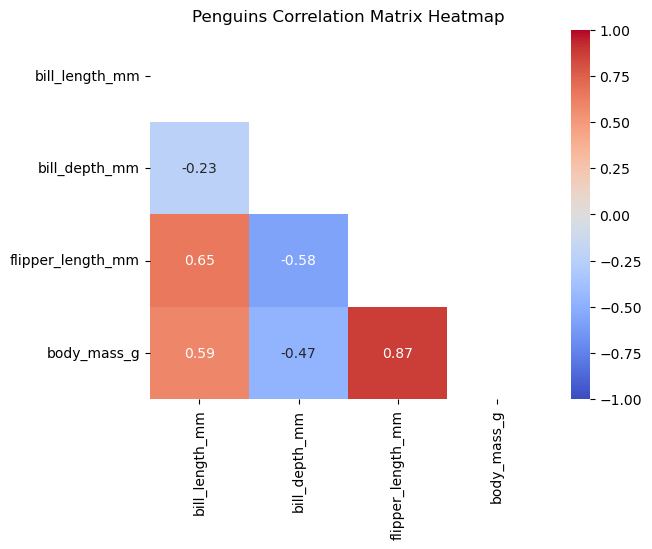

In [23]:
corr_matrix = penguins.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # 상삼각 행렬 마스크 생성

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            vmin=-1,
            vmax=1,
            mask=mask)        # 상삼각 행렬만 표시

plt.title('Penguins Correlation Matrix Heatmap')
plt.show()

## 서브플롯 관리

여러 개의 그래프를 원하는 모양과 크기로 한번에 배치하려면 `Figure` 객체와 서브플롯<font size='2'>subplot</font>을 활용한다.
`Figure`는 그림 액자, 서브플롯은 그 액자 안에 배치되는 도화지에 해당한다.

서브플롯 격자는 `plt.subplots()` 또는 `fig.add_subplot()`으로 생성하며, 각 격자 칸에 세 가지 방식으로
그래프를 추가할 수 있다.

- 방식 2(`df.plot.X()`, `df.boxplot()` 등)와 방식 3(`sns.histplot()`, `sns.scatterplot()` 등)은 함수의 `ax` 키워드 인자를 이용하여 격자 칸을 지정한다.
- `seaborn`의 `lmplot()`, `pairplot()` 등 소위 figure-level 함수는 자체 `FacetGrid`를 만들기 때문에 서브플롯 격자 안에 배치할 수 없다.

세 가지 개념의 관계는 다음과 같다.

- **`Figure`**: 전체 그림 액자. `plt.figure()` 또는 `plt.subplots()`로 생성하며, 하나 이상의 서브플롯을 담는다.
- **서브플롯**: Figure 안에 배치된 개별 그래프 영역. `fig.add_subplot()` 또는 `plt.subplots()`로 생성한다.
- **`Axes`**: 각 서브플롯에 대응하는 `matplotlib` 객체(`ax`). 실제 그래프가 그려지는 좌표계이며, `ax.scatter()`, `ax.hist()` 등 메서드로 그래프를 그린다.

서브플롯과 `Axes`는 일대일로 대응한다. 즉, 서브플롯 하나 = `Axes` 객체 하나이다.

### Figure와 단일 서브플롯

다음 두 코드는 동일한 산점도를 그린다.
첫 번째는 `plt.scatter()`를 직접 호출하는 간단한 방식이고,
두 번째는 `Figure` 객체를 만들어 서브플롯을 추가하는 방식이다.
그래프 하나를 그릴 때는 첫 번째 방식이 간편하지만,
여러 그래프를 한꺼번에 배치하려면 두 번째 방식이 훨씬 유용하다.

**그래프 코드 1**

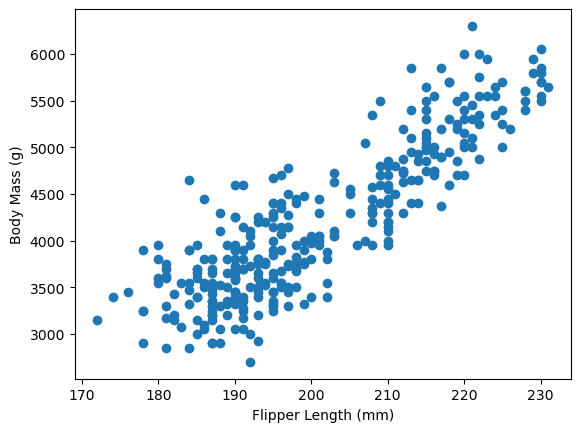

In [24]:
plt.scatter(penguins['flipper_length_mm'], penguins['body_mass_g'])

plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')
plt.show()

**그래프 코드 2**

아래 코드는 먼저 `Figure` 객체를 생성한 후에 
1x1 모양의 격자 서브플롯을 지정하고, 생성된 서브플롯을 `ax` 변수에 할당한다.
생성된 서브플롯은 `Axes` 객체이며, `ax.scatter()`, `ax.hist()` 등
직접 그래프를 그리는 메서드를 제공하며,
`plt.scatter()`, `plt.hist()` 등과는 달리 지정된 서브플롯에 그래프를 그린다.

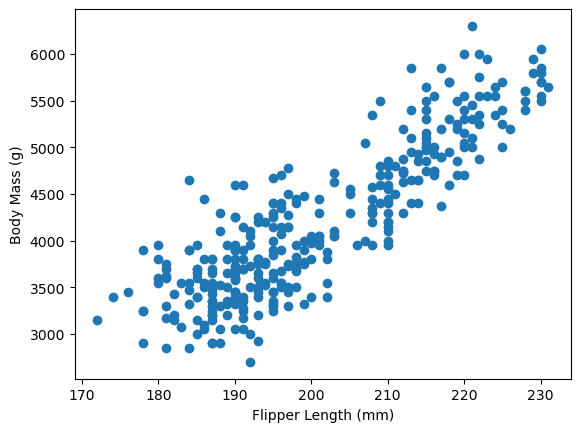

In [25]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1) # 1행 1열의 첫 번째 서브플롯(Axes 객체) 생성

# Axes 객체는 자신 서브플롯에 직접 그래프를 그리는 메서드를 제공
ax.scatter(penguins['flipper_length_mm'], penguins['body_mass_g'])

ax.set_xlabel('Flipper Length (mm)')
ax.set_ylabel('Body Mass (g)')

plt.show()

**`Figure` 객체**

`Figure` 객체는 아래 코드로 생성한다. 생성된 객체는 그림 액자의 기능을 수행한다.

```python
fig = plt.figure()
```

<div align="center">
    <img src="https://github.com/codingalzi/code-workout-datasci/blob/master/images/figures.png?raw=true" style="width:500px">
</div>

<p style='text-align:center;'>그림 출처: <a href='https://velog.io/@regista/Matplotlib에서-Figure와-Axes-이해하기-Basic'>Matplotlib에서 Figure와 Axes 이해하기</a></p>

**단일 서브플롯 추가**

서브플롯<font size='2'>subplot</font>은 그래프를 그릴 때 필요한 도화지에 해당한다.
아래 코드는 준비된 `Figure` 객체에 하나의 서브플롯, 즉 
액자에 딱 맞는 한 장의 도화지를 추가한다.

```python
ax = fig.add_subplot(1, 1, 1)
```

<div align="center">
    <img src="https://github.com/codingalzi/code-workout-datasci/blob/master/images/figures_subplots.png?raw=true" style="width:600px">
</div>

<p style='text-align:center;'>그림 출처: <a href='https://velog.io/@regista/Matplotlib에서-Figure와-Axes-이해하기-Basic'>Matplotlib에서 Figure와 Axes 이해하기</a></p>

### 격자 형식 서브플롯

아래 코드는 두 개의 서브플롯을 (1, 2) 모양의 격자 형식으로 추가한다.
즉, 액자에 두 장의 도화지를 좌우로 배치시키는 효과를 낸다.

```python
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)
```

<div align="center">
    <img src="https://github.com/codingalzi/code-workout-datasci/blob/master/images/figures_subplots121.png?raw=true" style="width:600px">
</div>

<p style='text-align:center;'>그림 출처: <a href='https://velog.io/@regista/Matplotlib에서-Figure와-Axes-이해하기-Basic'>Matplotlib에서 Figure와 Axes 이해하기</a></p>

**`add_subplot()` 메서드의 인자**

`add_subplot()` 메서드는 서브플롯을 격자 모양으로 배치할 때 필요한 세 개의 정보를 인자로 받는다.

- 첫째 인자: 행의 개수
- 둘째 인자: 열의 개수
- 셋째 인자: 생성되는 서브플롯의 인덱스(1부터 시작, 왼쪽 위에서 오른쪽 아래로)

**`Axes` 객체**

이전 코드에서 정의된
`ax1`과 `ax2` 두 변수는 (1, 2) 모양으로 배치된 두 개의 서브플롯 위치 정보를 담은 `Axes` 객체를 가리킨다.

- `ax1`: (1, 2) 모양으로 배치된 두 개의 서브플롯 중에서 첫째, 즉 왼편에 위치한 서브플롯의 위치 정보
- `ax2`: (1, 2) 모양으로 배치된 두 개의 서브플롯 중에서 둘째, 즉 오른편에 위치한 서브플롯의 위치 정보

특정 서브플롯에 그래프를 그리려면 해당 서브플롯의 위치 정보를 가리키는 `ax1` 또는 `ax2`를 선택하여
`scatter()`, `hist()` 같은 메서드를 호출한다.
예를 들어 `ax1.scatter(x, y)`는 왼쪽 도화지에 산점도를 그리고, `ax2.hist(data)`는 오른쪽 도화지에 히스토그램을 그린다.

**예제 1. 좌우 배치: (1, 2)**

두 개의 서브플롯을 좌우로 나란히 배치하려면 `add_subplot(1, 2, ...)`를 사용한다.
아래 코드는 부리 길이와 몸무게의 산점도를 좌우로 비교한다.

- `plt.figure()` 함수의 `figsize` 키워드 인자는 `Figure` 크기의 사로 세로 크기와 비율을 지정한다.
- `ax1.set_xlabel()`, `ax1.set_title()` 등으로 서브플롯 각각에 축 이름과 타이틀을 별도로 지정한다.
- `plt.suptitle()` 함수는 `Figure` 객체 전체에 대한 타이틀을 지정한다.

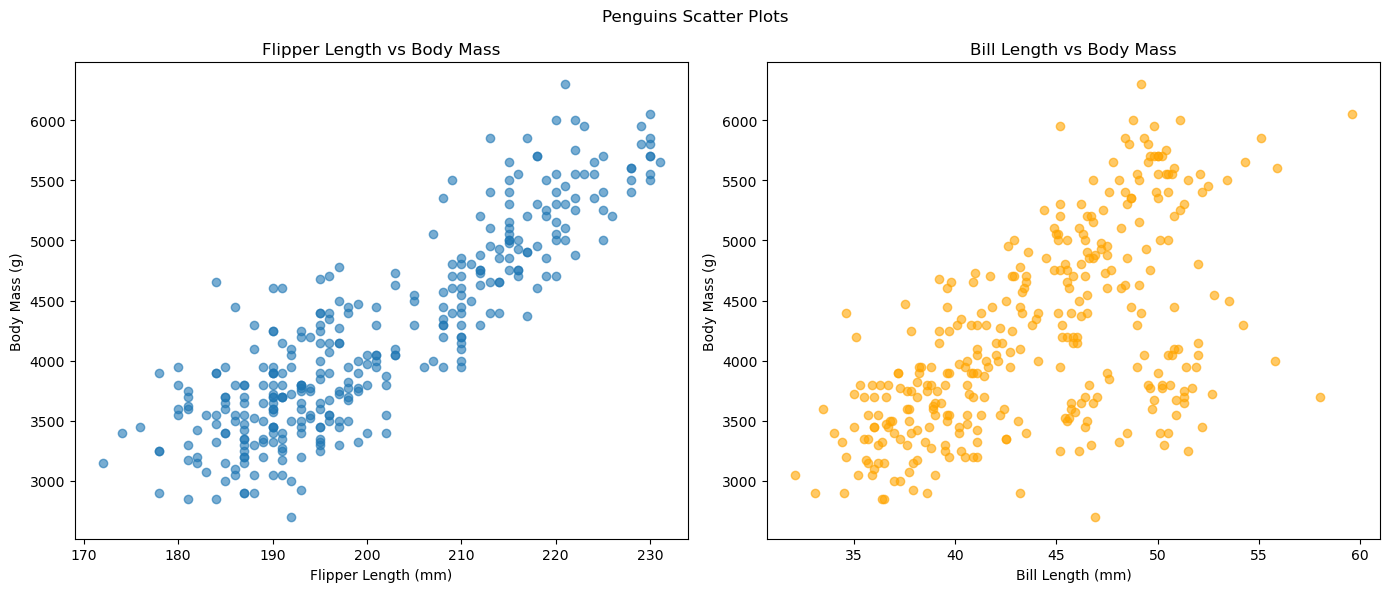

In [26]:
fig = plt.figure(figsize=(14, 6))

# 왼쪽 도화지
ax1 = fig.add_subplot(1, 2, 1)
# 오른쪽 도화지
ax2 = fig.add_subplot(1, 2, 2)

# 왼쪽: 날개 길이 vs 몸무게
ax1.scatter(penguins['flipper_length_mm'], penguins['body_mass_g'], alpha=0.6)
ax1.set_xlabel('Flipper Length (mm)')
ax1.set_ylabel('Body Mass (g)')
ax1.set_title('Flipper Length vs Body Mass')

# 오른쪽: 부리 길이 vs 몸무게
ax2.scatter(penguins['bill_length_mm'], penguins['body_mass_g'], alpha=0.6, color='orange')
ax2.set_xlabel('Bill Length (mm)')
ax2.set_ylabel('Body Mass (g)')
ax2.set_title('Bill Length vs Body Mass')

plt.suptitle('Penguins Scatter Plots') # 전체 제목
plt.tight_layout() # 레이아웃 조정
plt.show()

**예제 2. 위아래 배치: (2, 1)**

두 개의 서브플롯을 위아래로 배치하려면 `add_subplot(2, 1, ...)`을 사용하고,
`figsize`의 둘째 값(세로)을 더 크게 설정해야 비율이 자연스러워진다.

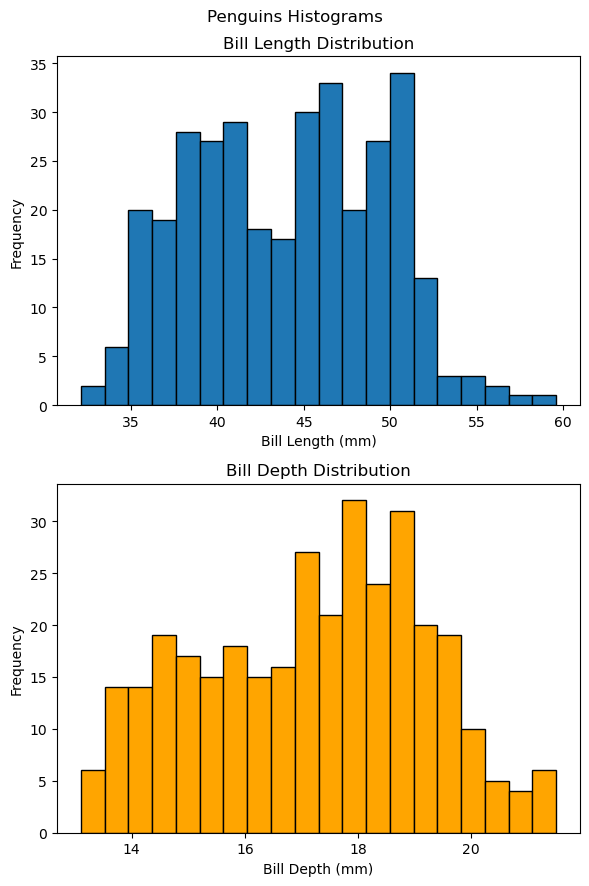

In [27]:
fig = plt.figure(figsize=(6, 9))

# 위쪽 도화지
ax1 = fig.add_subplot(2, 1, 1)
# 아래쪽 도화지
ax2 = fig.add_subplot(2, 1, 2)

ax1.hist(penguins['bill_length_mm'], bins=20, edgecolor='black')
ax1.set_xlabel('Bill Length (mm)')
ax1.set_ylabel('Frequency')
ax1.set_title('Bill Length Distribution')

ax2.hist(penguins['bill_depth_mm'], bins=20, edgecolor='black', color='orange')
ax2.set_xlabel('Bill Depth (mm)')
ax2.set_ylabel('Frequency')
ax2.set_title('Bill Depth Distribution')

plt.suptitle('Penguins Histograms')
plt.tight_layout()
plt.show()

**예제 3. 격자 배치: (2, 2)**

아래 코드는 네 개의 수치형 특성에 대한 히스토그램을 (2, 2) 모양의 격자에 배치한다.
각 서브플롯의 인덱스는 1, 2, 3, 4 순서이며,
왼쪽 위 → 오른쪽 위 → 왼쪽 아래 → 오른쪽 아래 순서로 채워진다.

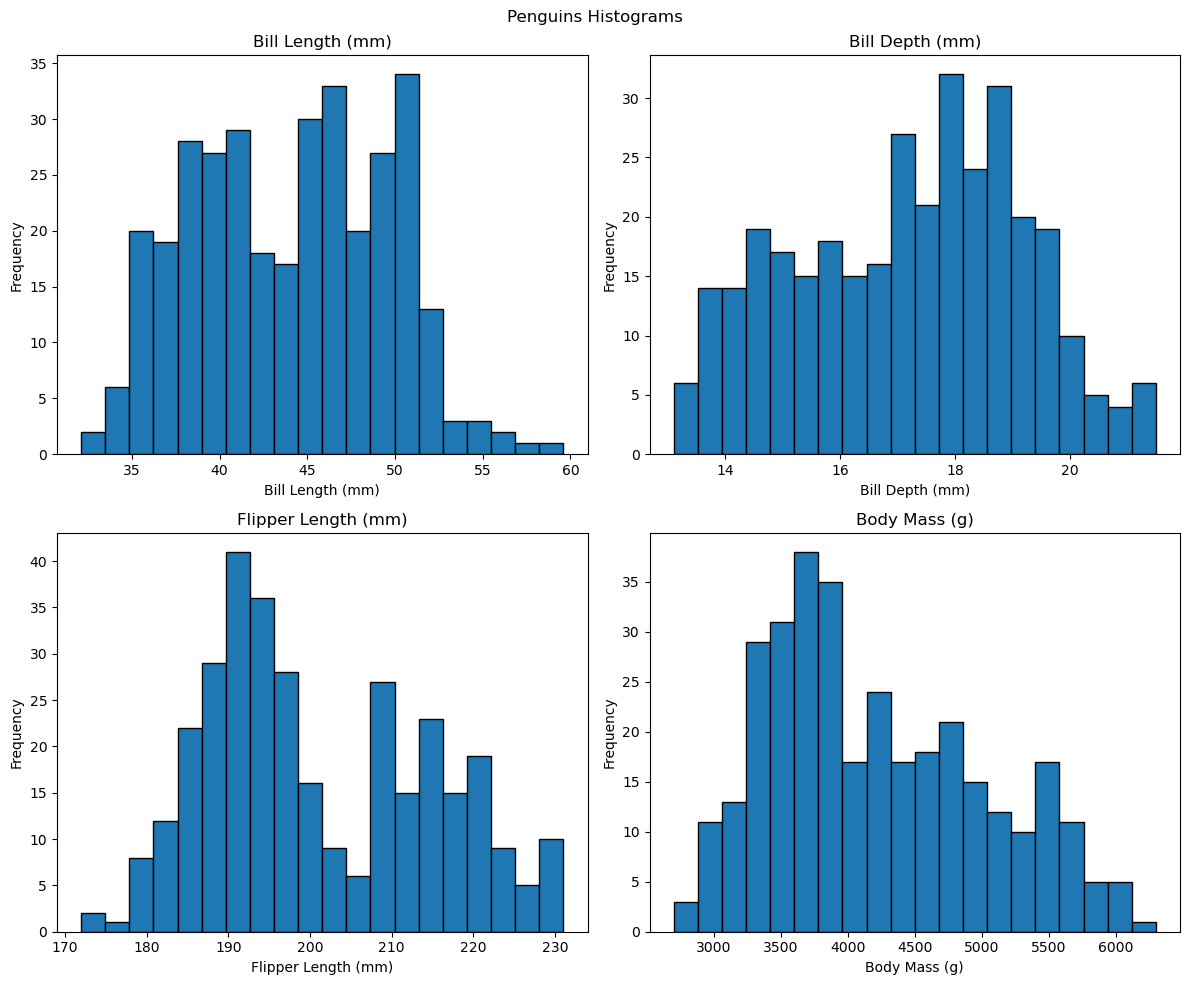

In [28]:
fig = plt.figure(figsize=(12, 10))

features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
titles = ['Bill Length (mm)', 'Bill Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)']

for i, (feat, title) in enumerate(zip(features, titles), start=1):
    ax = fig.add_subplot(2, 2, i)
    ax.hist(penguins[feat], bins=20, edgecolor='black')
    ax.set_xlabel(title)
    ax.set_ylabel('Frequency')
    ax.set_title(title)

plt.suptitle('Penguins Histograms')
plt.tight_layout()
plt.show()

### `plt.subplots()` 함수

`plt.subplots()` 함수는 `Figure` 객체와 모든 서브플롯의 `Axes` 객체를 한꺼번에 생성한다.
결과로 반환되는 `axes`는 2차원 배열이며, `axes[i, j]`로 각 위치의 서브플롯에 접근한다.
아래 코드는 종별로 색상을 달리하여 네 가지 산점도를 (2, 2)로 배치한다.

:::{note} `plt.subplot()` 함수 반환값

`plt.subplots()` 함수는 두 개의 값을 튜플로 반환한다.
예를 들어, 아래 코드에서 `fig`와 `axes`는 각각 `Figure` 객체와 (2, 2) 모양의 2차원 `numpy` 어레이다.
배열의 항목은 각 서브플롯의 `Axes` 객체가 자리하며, 
`axes[i, j]` 처럼 2차원 어레이 인덱싱으로 확인된다.
:::

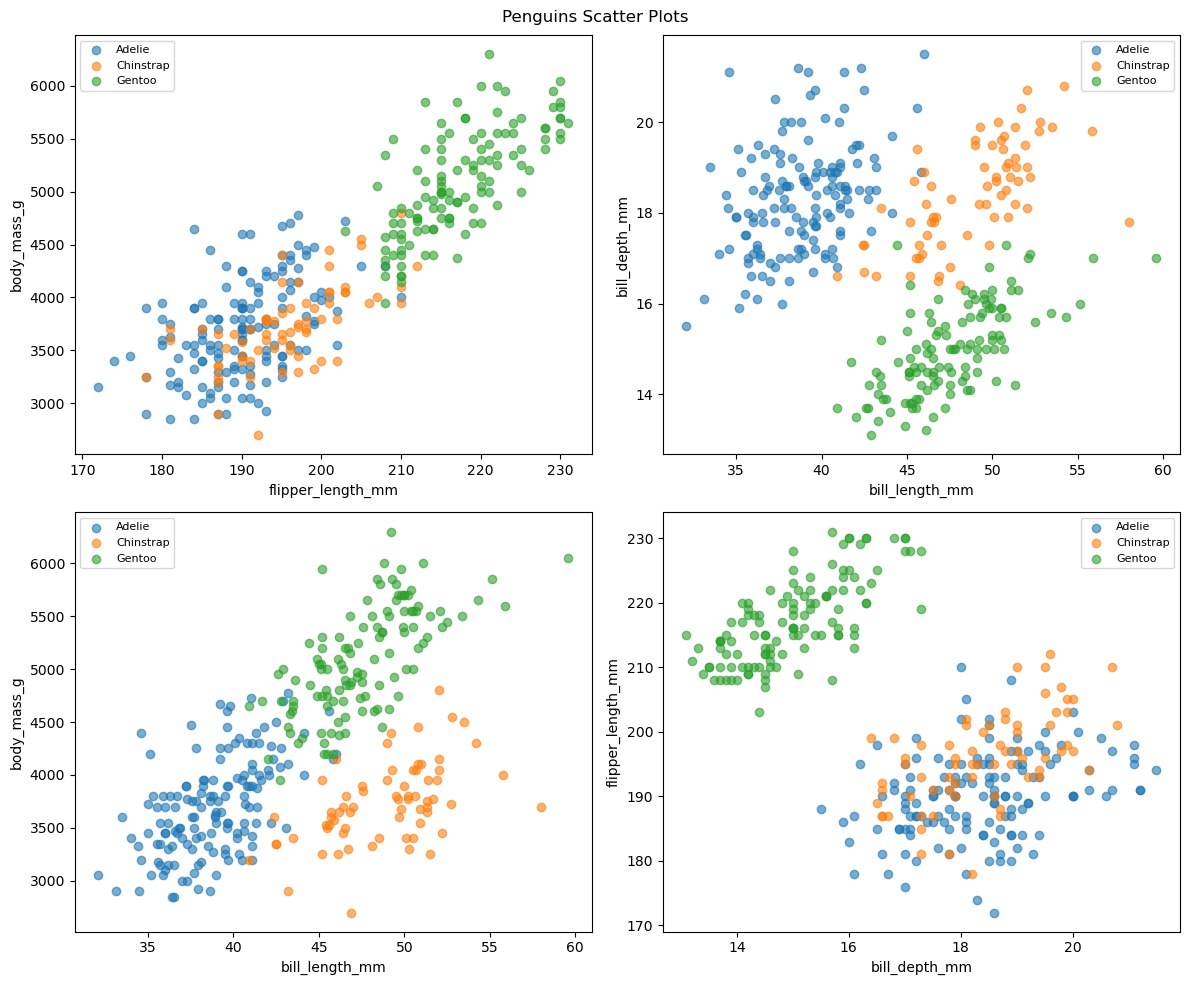

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

pairs = [
    ('flipper_length_mm', 'body_mass_g'),
    ('bill_length_mm', 'bill_depth_mm'),
    ('bill_length_mm', 'body_mass_g'),
    ('bill_depth_mm', 'flipper_length_mm'),
]
colors = {'Adelie': 'tab:blue', 'Chinstrap': 'tab:orange', 'Gentoo': 'tab:green'}

for ax, (x, y) in zip(axes.flat, pairs):
    for sp, group in penguins.groupby('species'):
        ax.scatter(group[x], group[y], alpha=0.6, label=sp, color=colors[sp])
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.legend(fontsize=8)

plt.suptitle('Penguins Scatter Plots')
plt.tight_layout()
plt.show()

### 세 방식 섞어 쓰기

각 서브플롯 칸에는 세 가지 방식을 모두 섞어 쓸 수 있다.
방식 2의 `df.plot.X()`, `df.boxplot()` 등과 
방식 3의 `ax` 키워드 인자를 받는 함수(`sns.histplot()`, `sns.scatterplot()`, `sns.boxplot()`, `sns.regplot()` 등)는
모두 `ax` 키워드 인자로 대상 서브플롯 칸을 지정한다.

:::{warning} `ax` 키워드 인자 사용 여부

방식 2와 3 모두 `ax` 키워드 인자를 빠뜨리면 자신만의 `Figure` 객체를 새로 만들어 사용한다.
즉, 격자 밖에 따로 그래프가 그려진다.
:::

**예제 1.**

산점도 한 종류를 세 방식으로 나란히 그려 보면, 각 방식이 어떻게 `ax` 키워드 인자와 결합되는지 한눈에 확인할 수 있다.

- 왼쪽: 방식 1 — `ax.scatter()`
- 가운데: 방식 2 — `df.plot.scatter(..., ax=...)`
- 오른쪽: 방식 3 — `sns.scatterplot(..., ax=...)`

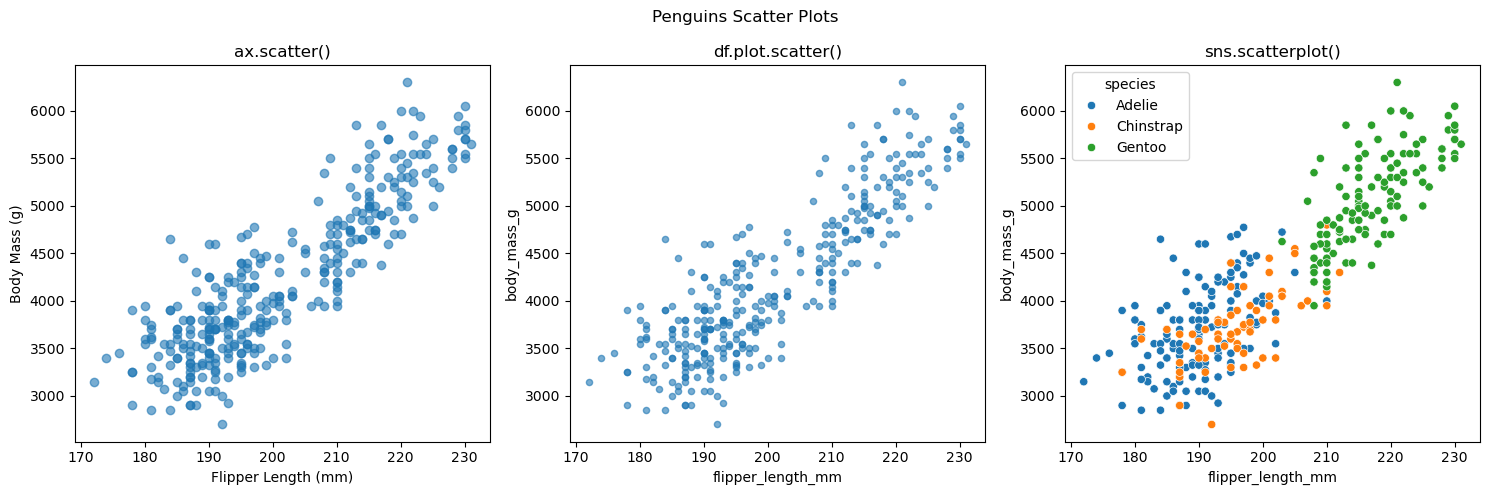

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 왼쪽: 방식 1
axes[0].scatter(penguins['flipper_length_mm'], penguins['body_mass_g'], alpha=0.6)
axes[0].set_xlabel('Flipper Length (mm)')
axes[0].set_ylabel('Body Mass (g)')
axes[0].set_title('ax.scatter()')

# 가운데: 방식 2
penguins.plot.scatter(x='flipper_length_mm', y='body_mass_g',
                      alpha=0.6, ax=axes[1])
axes[1].set_title('df.plot.scatter()')

# 오른쪽: 방식 3
sns.scatterplot(data=penguins, x='flipper_length_mm', y='body_mass_g',
                hue='species', ax=axes[2])
axes[2].set_title('sns.scatterplot()')

plt.suptitle('Penguins Scatter Plots')
plt.tight_layout()
plt.show()

**예제 2.**

한 격자에 산점도, 회귀선, 히스토그램, 상자 그림을 각각 다른 방식으로 그려 본다.

- 좌상단: 방식 1 — `ax.scatter()` (어레이 직접 입력)
- 우상단: 방식 2 — `df.plot.scatter(..., ax=...)` (데이터프레임 메서드)
- 좌하단: 방식 3 — `sns.histplot(..., hue='species', ax=...)` (종별 분포)
- 우하단: 방식 3 — `sns.boxplot(..., ax=...)` (종별 상자 그림)

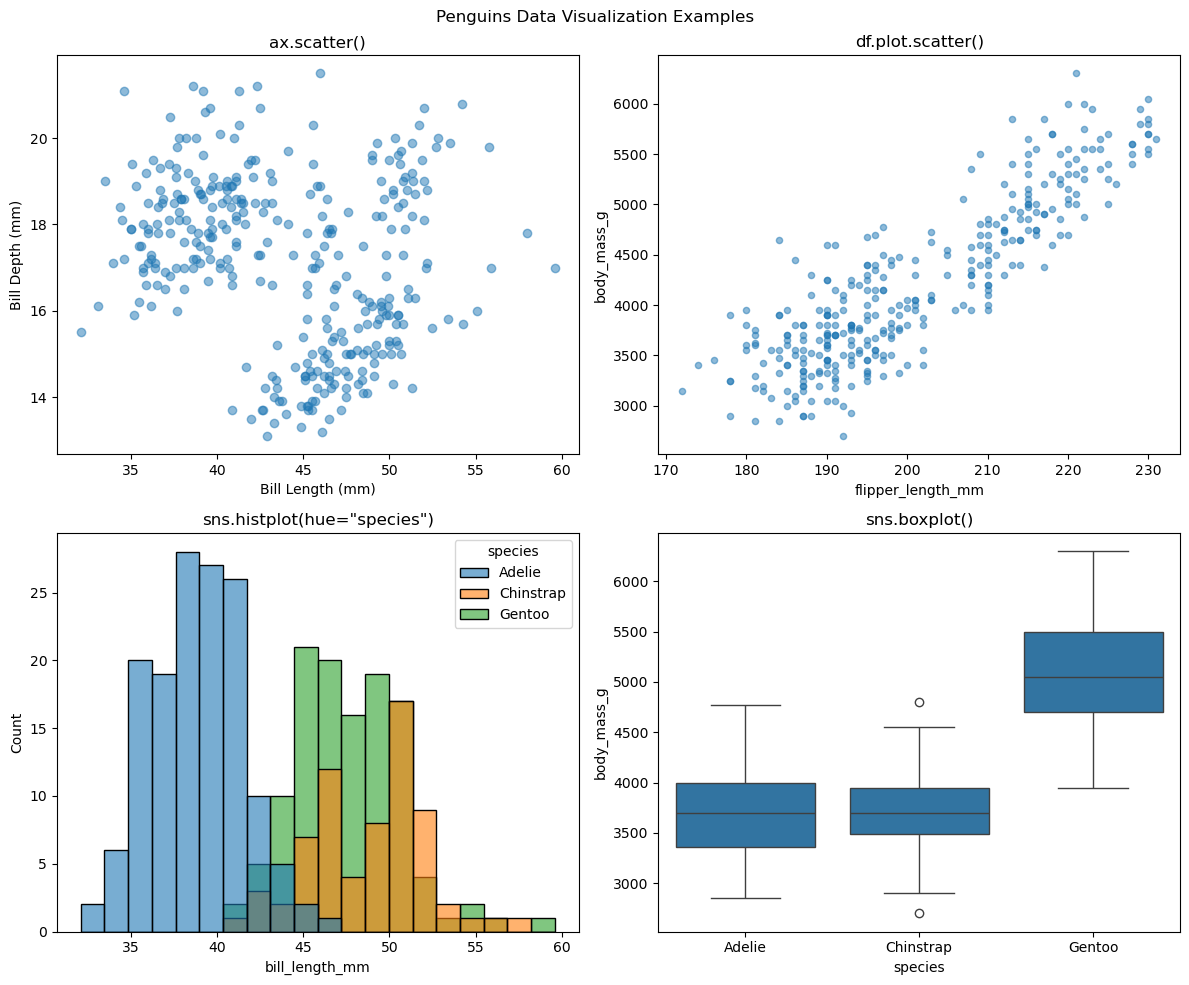

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# (0, 0) 방식 1: 어레이로 직접 산점도
axes[0, 0].scatter(penguins['bill_length_mm'].values,
                   penguins['bill_depth_mm'].values, alpha=0.5)
axes[0, 0].set_xlabel('Bill Length (mm)')
axes[0, 0].set_ylabel('Bill Depth (mm)')
axes[0, 0].set_title('ax.scatter()')

# (0, 1) 방식 2: 데이터프레임 메서드 산점도
penguins.plot.scatter(x='flipper_length_mm', y='body_mass_g',
                      alpha=0.5, ax=axes[0, 1])
axes[0, 1].set_title('df.plot.scatter()')

# (1, 0) 방식 3: 종별 히스토그램
sns.histplot(data=penguins, x='bill_length_mm', hue='species',
             bins=20, alpha=0.6, ax=axes[1, 0])
axes[1, 0].set_title('sns.histplot(hue="species")')

# (1, 1) 방식 3: 종별 상자 그림
sns.boxplot(data=penguins, x='species', y='body_mass_g', ax=axes[1, 1])
axes[1, 1].set_title('sns.boxplot()')

plt.suptitle('Penguins Data Visualization Examples')
plt.tight_layout()
plt.show()

**예제 3.**

방식 1의 `axes.flat`을 활용한 반복문과 방식 3 axes-level 함수를 결합하면,
수치형 특성 4개의 종별 분포를 한 번에 비교할 수 있다.

:::{note}

아래 코드에서 `axes.flat`은 이 `axes`가 가리키는 2차원 배열을 1차원으로 펼친 이터레이터이다.
`zip(axes.flat, features)`처럼 반복문에서 각 서브플롯 칸을 순서대로 접근할 때 편리하다.
:::

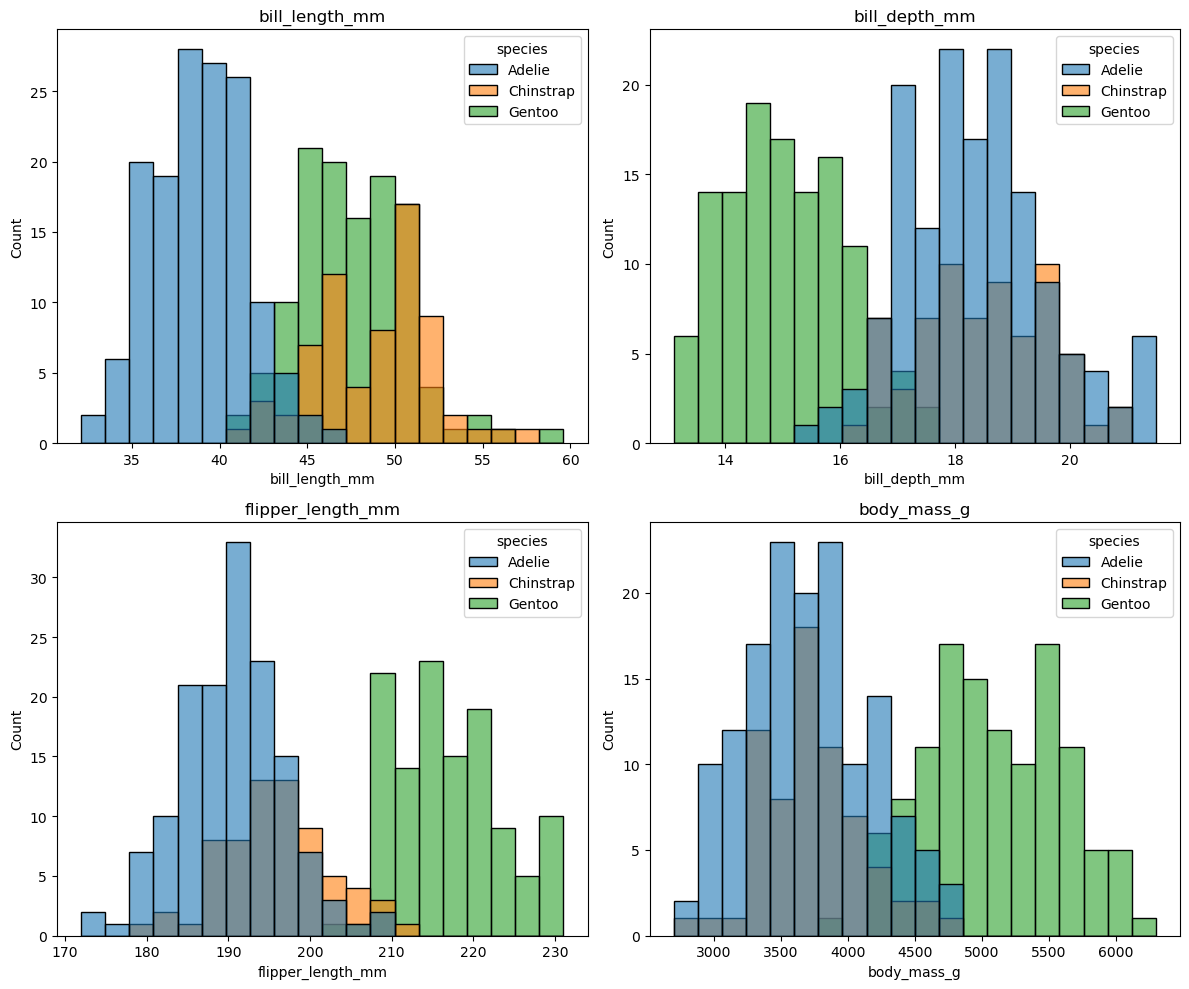

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

for ax, feat in zip(axes.flat, features):
    sns.histplot(data=penguins, x=feat, hue='species',
                 bins=20, alpha=0.6, ax=ax)
    ax.set_title(feat)

plt.tight_layout()
plt.show()

**예제 4. 펭귄 데이터 시각화 대시보드**

지금까지 익힌 시각화 기법과 서브플롯 관리를 결합하여,
한 화면에서 펭귄 데이터를 다각도로 살펴보는 대시보드를 만든다.

- 좌상단: 종별 부리 길이 히스토그램
- 우상단: 종별 몸무게 상자 그림
- 좌하단: 날개 길이와 몸무게 산점도(종별 색상)
- 우하단: 부리 길이와 부리 두께 산점도(종별 색상)

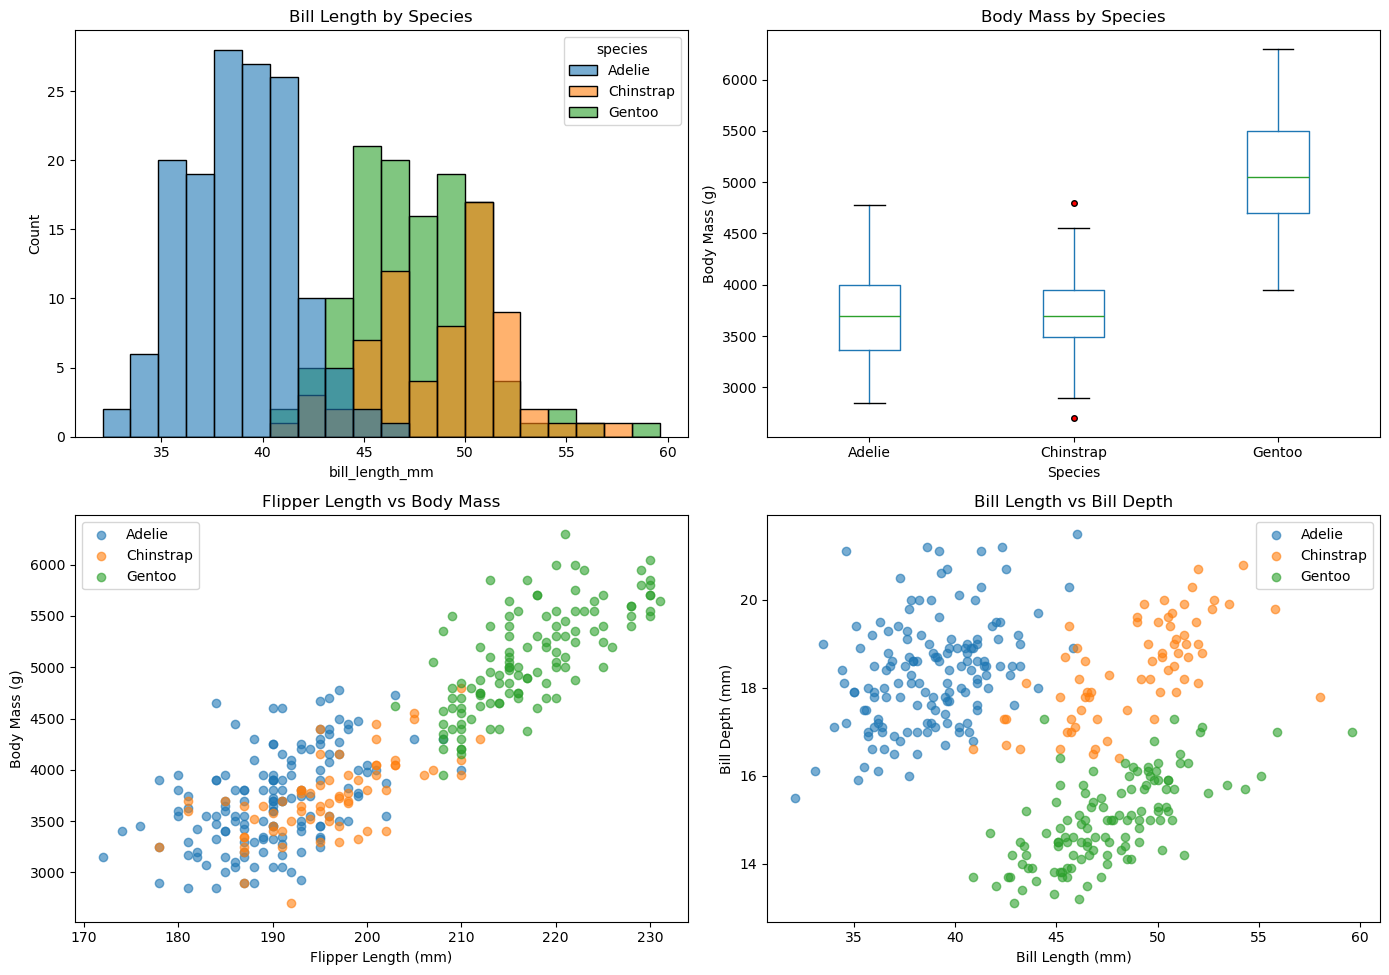

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 좌상단: 종별 부리 길이 히스토그램
sns.histplot(data=penguins, x='bill_length_mm', hue='species',
             bins=20, alpha=0.6, ax=axes[0, 0])
axes[0, 0].set_title('Bill Length by Species')

# 우상단: 종별 몸무게 상자 그림
penguins.boxplot(column='body_mass_g', by='species',
                 grid=False, ax=axes[0, 1],
                 flierprops=dict(marker='o', markerfacecolor='red', markersize=4))
axes[0, 1].set_title('Body Mass by Species')
axes[0, 1].set_xlabel('Species')
axes[0, 1].set_ylabel('Body Mass (g)')

# 좌하단: 날개 길이 vs 몸무게 산점도 (종별 색상)
colors = {'Adelie': 'tab:blue', 'Chinstrap': 'tab:orange', 'Gentoo': 'tab:green'}
for sp, group in penguins.groupby('species'):
    axes[1, 0].scatter(group['flipper_length_mm'], group['body_mass_g'],
                       alpha=0.6, label=sp, color=colors[sp])
axes[1, 0].set_xlabel('Flipper Length (mm)')
axes[1, 0].set_ylabel('Body Mass (g)')
axes[1, 0].set_title('Flipper Length vs Body Mass')
axes[1, 0].legend()

# 우하단: 부리 길이 vs 부리 두께 산점도 (종별 색상)
for sp, group in penguins.groupby('species'):
    axes[1, 1].scatter(group['bill_length_mm'], group['bill_depth_mm'],
                       alpha=0.6, label=sp, color=colors[sp])
axes[1, 1].set_xlabel('Bill Length (mm)')
axes[1, 1].set_ylabel('Bill Depth (mm)')
axes[1, 1].set_title('Bill Length vs Bill Depth')
axes[1, 1].legend()

plt.suptitle('')    # boxplot이 자동으로 만든 상위 제목 제거
plt.tight_layout()
plt.show()

## 연습문제

식당 팁 데이터셋(`tips`)을 활용하여 앞에서 익힌 시각화 기법을 연습한다.

| 특성 | 의미 |
| :--- | :--- |
| `total_bill` | 총 결제 금액 ($) |
| `tip` | 팁 금액 ($) |
| `sex` | 성별 (Male, Female) |
| `smoker` | 흡연 여부 (Yes, No) |
| `day` | 요일 (Thur, Fri, Sat, Sun) |
| `time` | 식사 시간 (Lunch, Dinner) |
| `size` | 일행 수 |

In [34]:
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


그래프 전역 설정을 바꾸면 그래프 스타일이 어떻게 달라지는지 함께 확인하라.

In [35]:
plt.rc('figure', figsize=(8, 6))
plt.rc('font',   size=12)
plt.rc('axes',   labelsize=14, titlesize=14)
plt.rc('legend', fontsize=12)
plt.rc('xtick',  labelsize=12)
plt.rc('ytick',  labelsize=12)

**문제 1: 단일 플롯 시각화**

(1) `total_bill` 특성에 대한 히스토그램을 구간 폭 2달러로 그려라.

힌트: `np.arange(min, max + 2, 2)`로 구간 경계를 만들고 `plt.hist()` 또는 `Series.hist()`에 전달한다.

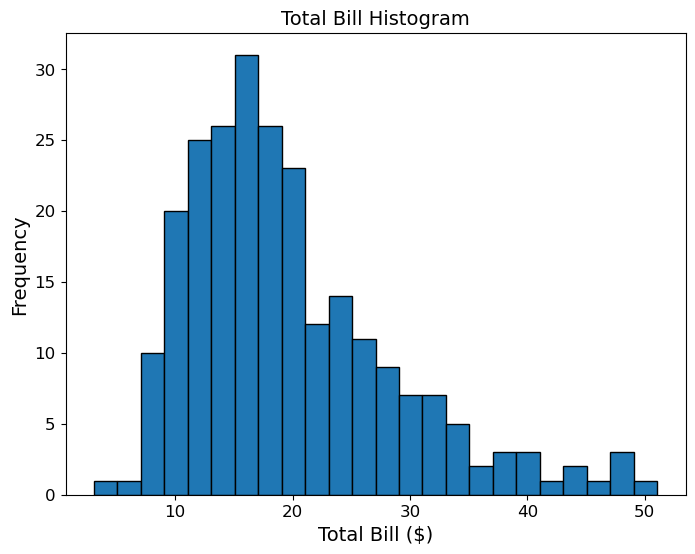

In [36]:
tb = tips['total_bill']
bins = np.arange(tb.min(), tb.max() + 2, 2)

plt.hist(tb, bins=bins, edgecolor='black')

plt.xlabel('Total Bill ($)')
plt.ylabel('Frequency')
plt.title('Total Bill Histogram')
plt.show()

(2) `seaborn`의 `histplot()`을 이용해 흡연 여부(`smoker`)에 따른 `total_bill` 분포를 비교하는 히스토그램을 그려라.

힌트: `hue='smoker'`를 인자로 사용한다.

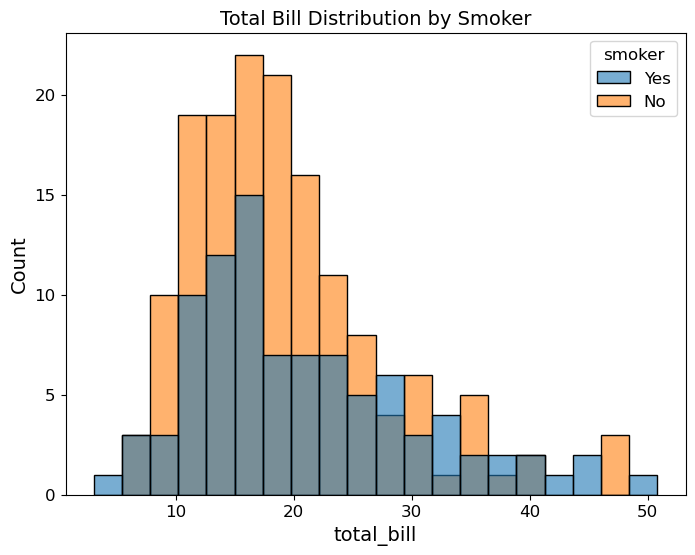

In [37]:
sns.histplot(data=tips, x='total_bill', hue='smoker', bins=20, alpha=0.6)

plt.title('Total Bill Distribution by Smoker')
plt.show()

(3) 요일(`day`)별로 그룹화한 `tip`의 상자 그림을 그려라.

힌트: `boxplot()` 메서드에 `by='day'`를 사용한다.

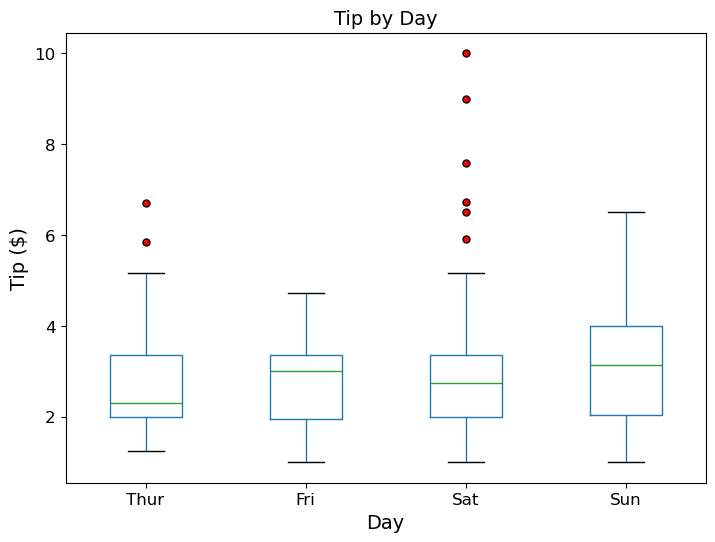

In [38]:
tips.boxplot(
    column=['tip'],
    by='day',
    grid=False,
    flierprops=dict(marker='o', markerfacecolor='red', markersize=5)
)

plt.suptitle('')
plt.title('Tip by Day')
plt.xlabel('Day')
plt.ylabel('Tip ($)')
plt.show()

**문제 2: 회귀선과 상관관계**

(1) `sns.regplot()`을 이용하여 `total_bill`과 `tip`의 산점도와 회귀선을 그려라.
단, `plt.figure()`에 `figsize=(6, 4)` 키워드 인자를 지정하여 그래프 크기를 기본 설정보다
작게 만든다.

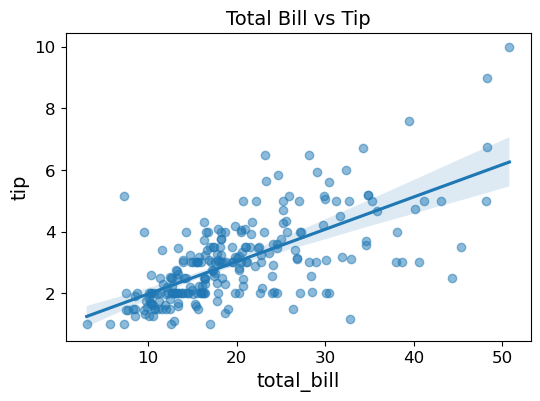

In [39]:
plt.figure(figsize=(6, 4))
sns.regplot(data=tips, x='total_bill', y='tip', scatter_kws={'alpha': 0.5})

plt.title('Total Bill vs Tip')
plt.show()

(2) `sns.lmplot()`을 이용하여 흡연 여부(`smoker`)별로 색상을 달리해 같은 산점도와 회귀선을 그려라.

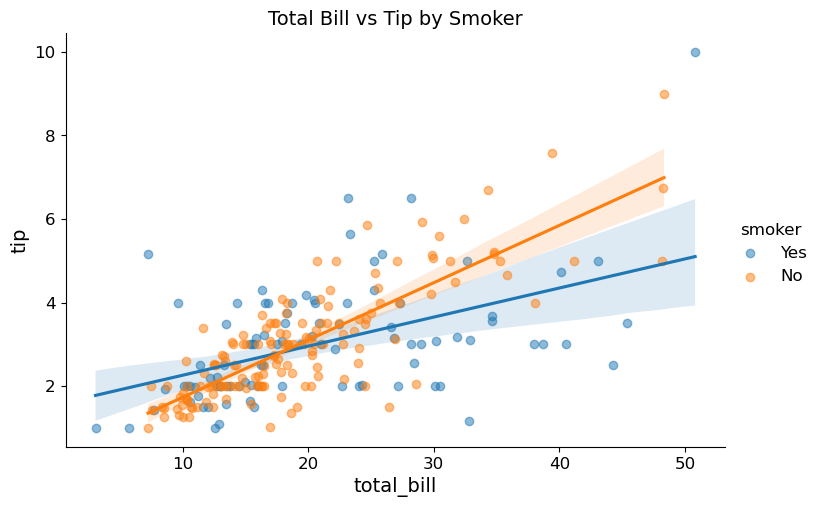

In [40]:
sns.lmplot(data=tips,
           x='total_bill',
           y='tip',
           hue='smoker',
           height=5,
           aspect=1.5,
           scatter_kws={'alpha': 0.5})

plt.title('Total Bill vs Tip by Smoker')
plt.show()

(3) `tips` 데이터의 수치형 특성에 대한 상관계수 행렬을 위쪽 삼각형을 마스킹한 히트맵으로 그려라.

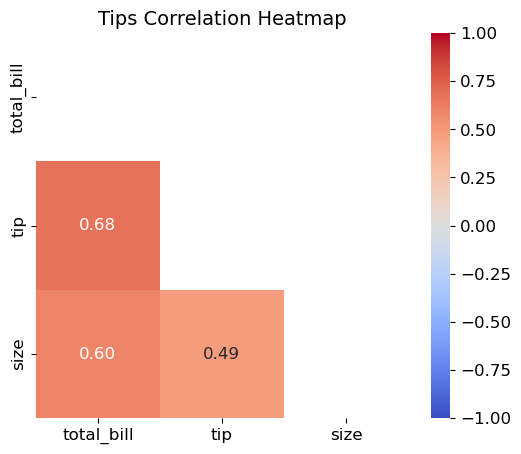

In [41]:
corr_matrix = tips.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            vmin=-1, vmax=1, mask=mask)
plt.title('Tips Correlation Heatmap')
plt.show()

**문제 3: 서브플롯 활용**

(1) `Figure`와 `add_subplot()`을 이용해 (1, 2) 모양으로 두 그래프를 좌우 배치하라.

- 왼쪽: `total_bill`의 히스토그램
- 오른쪽: `tip`의 히스토그램

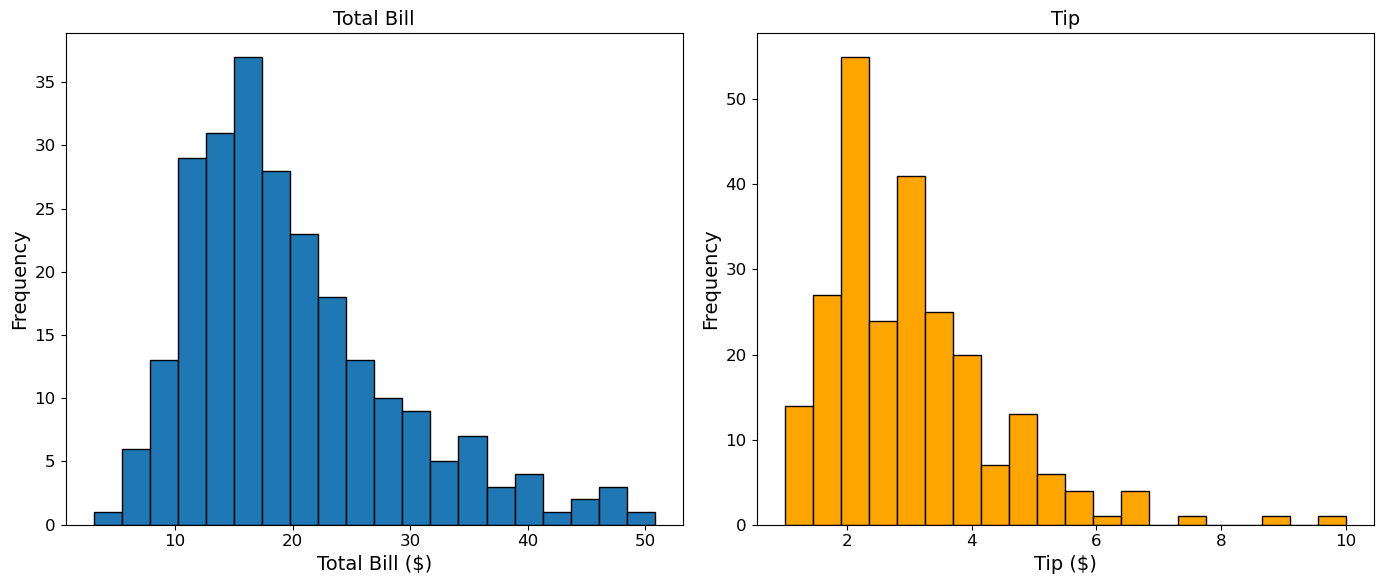

In [44]:
fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(1, 2, 1)
ax1.hist(tips['total_bill'], bins=20, edgecolor='black')
ax1.set_xlabel('Total Bill ($)')
ax1.set_ylabel('Frequency')
ax1.set_title('Total Bill')

ax2 = fig.add_subplot(1, 2, 2)
ax2.hist(tips['tip'], bins=20, edgecolor='black', color='orange')
ax2.set_xlabel('Tip ($)')
ax2.set_ylabel('Frequency')
ax2.set_title('Tip')

plt.tight_layout()
plt.show()

(2) `plt.subplots(2, 2)`와 `axes.flat`을 이용하여 `total_bill`과 `tip`의 성별(`sex`) 및 흡연 여부(`smoker`)별 히스토그램을 격자 모양으로 배치하라.

- (0, 0): 성별 `total_bill` 히스토그램
- (0, 1): 성별 `tip` 히스토그램
- (1, 0): 흡연 여부별 `total_bill` 히스토그램
- (1, 1): 흡연 여부별 `tip` 히스토그램

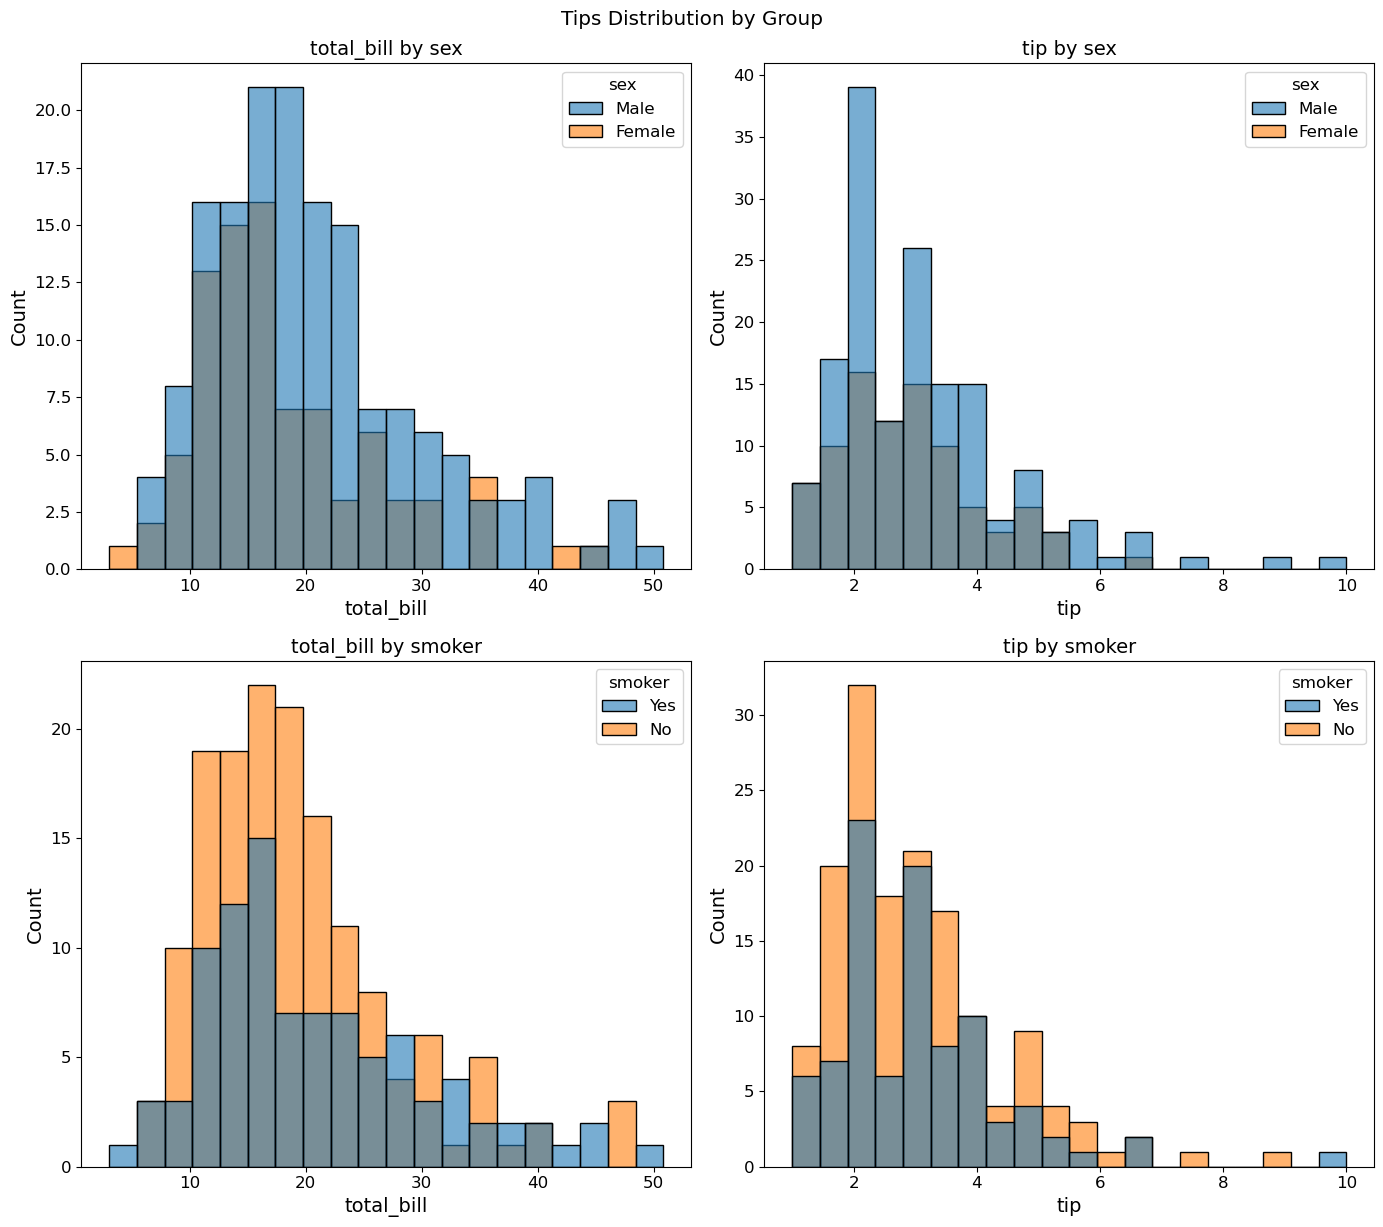

In [49]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12.5))

configs = [
    ('total_bill', 'sex'),
    ('tip',        'sex'),
    ('total_bill', 'smoker'),
    ('tip',        'smoker'),
]

for ax, (feat, hue) in zip(axes.flat, configs):
    sns.histplot(data=tips, x=feat, hue=hue, bins=20, alpha=0.6, ax=ax)
    ax.set_title(f'{feat} by {hue}')

plt.suptitle('Tips Distribution by Group')
plt.tight_layout()
plt.show()